In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import datasets, tree
from sklearn.tree import export_graphviz
from sklearn import externals
from io import StringIO
import pydotplus
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.image as mpimg

In [2]:
df=pd.read_csv(r"C:\Users\sanum\Desktop\assignment\assignments data\random forests\Company_Data (1).csv")

In [3]:
df1=df.copy()

In [4]:
df1.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [5]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,400.0,7.496325,2.824115,0.0,5.39,7.49,9.32,16.27
CompPrice,400.0,124.975000,15.334512,77.0,115.00,125.00,135.00,175.00
Income,400.0,68.657500,27.986037,21.0,42.75,69.00,91.00,120.00
Advertising,400.0,6.635000,6.650364,0.0,0.00,5.00,12.00,29.00
Population,400.0,264.840000,147.376436,10.0,139.00,272.00,398.50,509.00
Price,400.0,115.795000,23.676664,24.0,100.00,117.00,131.00,191.00
Age,400.0,53.322500,16.200297,25.0,39.75,54.50,66.00,80.00
Education,400.0,13.900000,2.620528,10.0,12.00,14.00,16.00,18.00


In [6]:
df1.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [7]:
df1.dtypes

Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

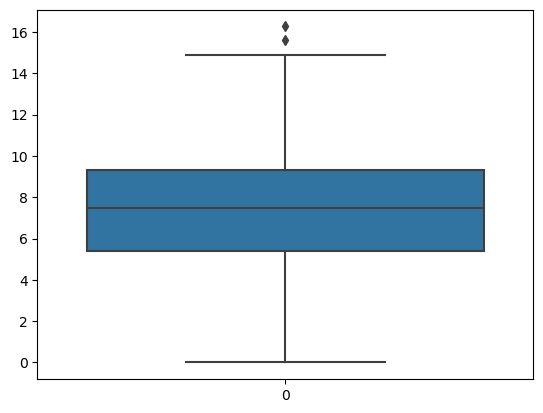

In [11]:
ax=sns.boxplot(df1['Sales'])

In [12]:
plt.rcParams["figure.figsize"]=9,5

Skew:0.18556036318721578
Kurtosis:-0.08087736743346197


C:\Users\sanum\AppData\Local\Temp\ipykernel_10336\1649085103.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax=sns.kdeplot(df1['Sales'],shade=True, color='g')


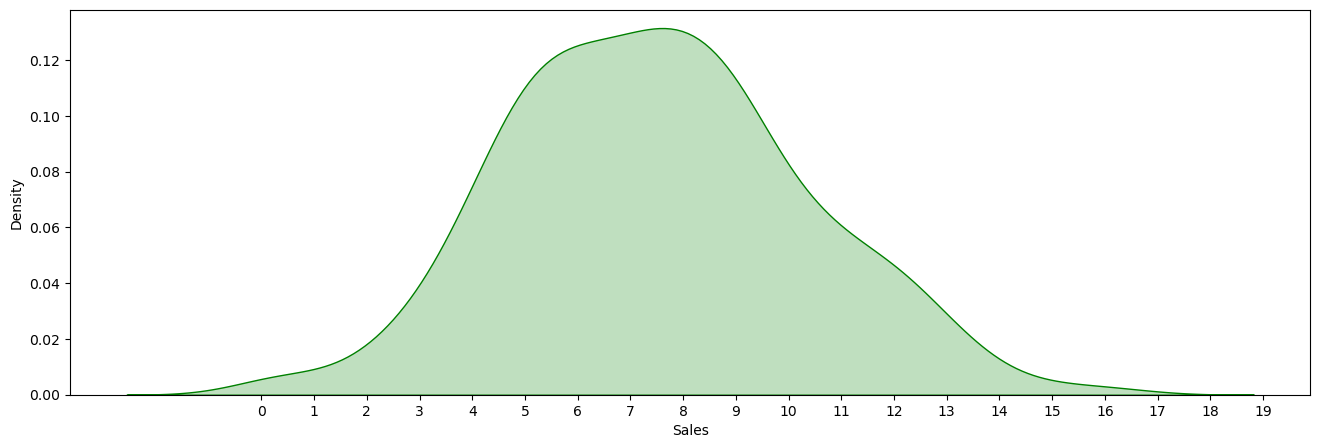

In [14]:
plt.figure(figsize=(16,5))
print("Skew:{}".format(df1['Sales'].skew()))
print("Kurtosis:{}".format(df1['Sales'].kurtosis()))
ax=sns.kdeplot(df1['Sales'],shade=True, color='g')
plt.xticks([i for i in range(0,20,1)])
plt.show()

In [17]:
obj_column=df1.select_dtypes(include='object').columns.tolist()

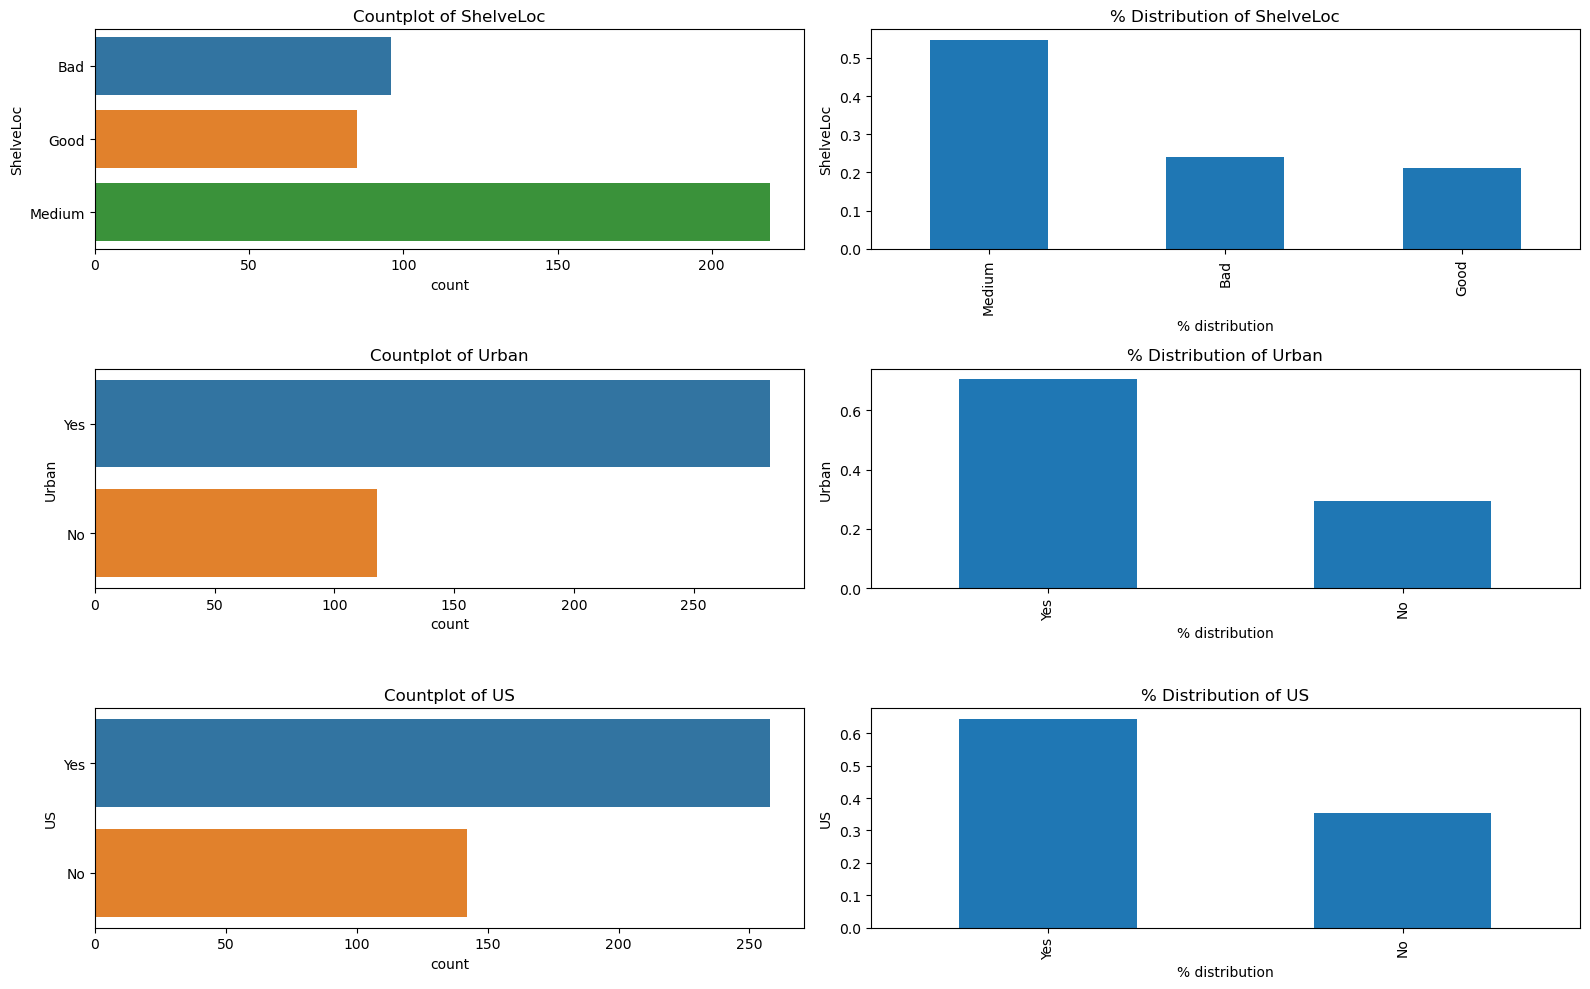

In [19]:
plt.figure(figsize=(16,10))

for i, col in enumerate(obj_column):
    
    # Countplot
    plt.subplot(3,2,2*i+1)
    sns.countplot(data=df1, y=col)
    plt.title(f"Countplot of {col}")
    
    # Percentage plot
    plt.subplot(3,2,2*i+2)
    df1[col].value_counts(normalize=True).plot.bar()
    plt.title(f"% Distribution of {col}")
    plt.ylabel(col)
    plt.xlabel('% distribution')

plt.tight_layout()
plt.show()

In [20]:
num_columns=df1.select_dtypes(exclude='object').columns.tolist()

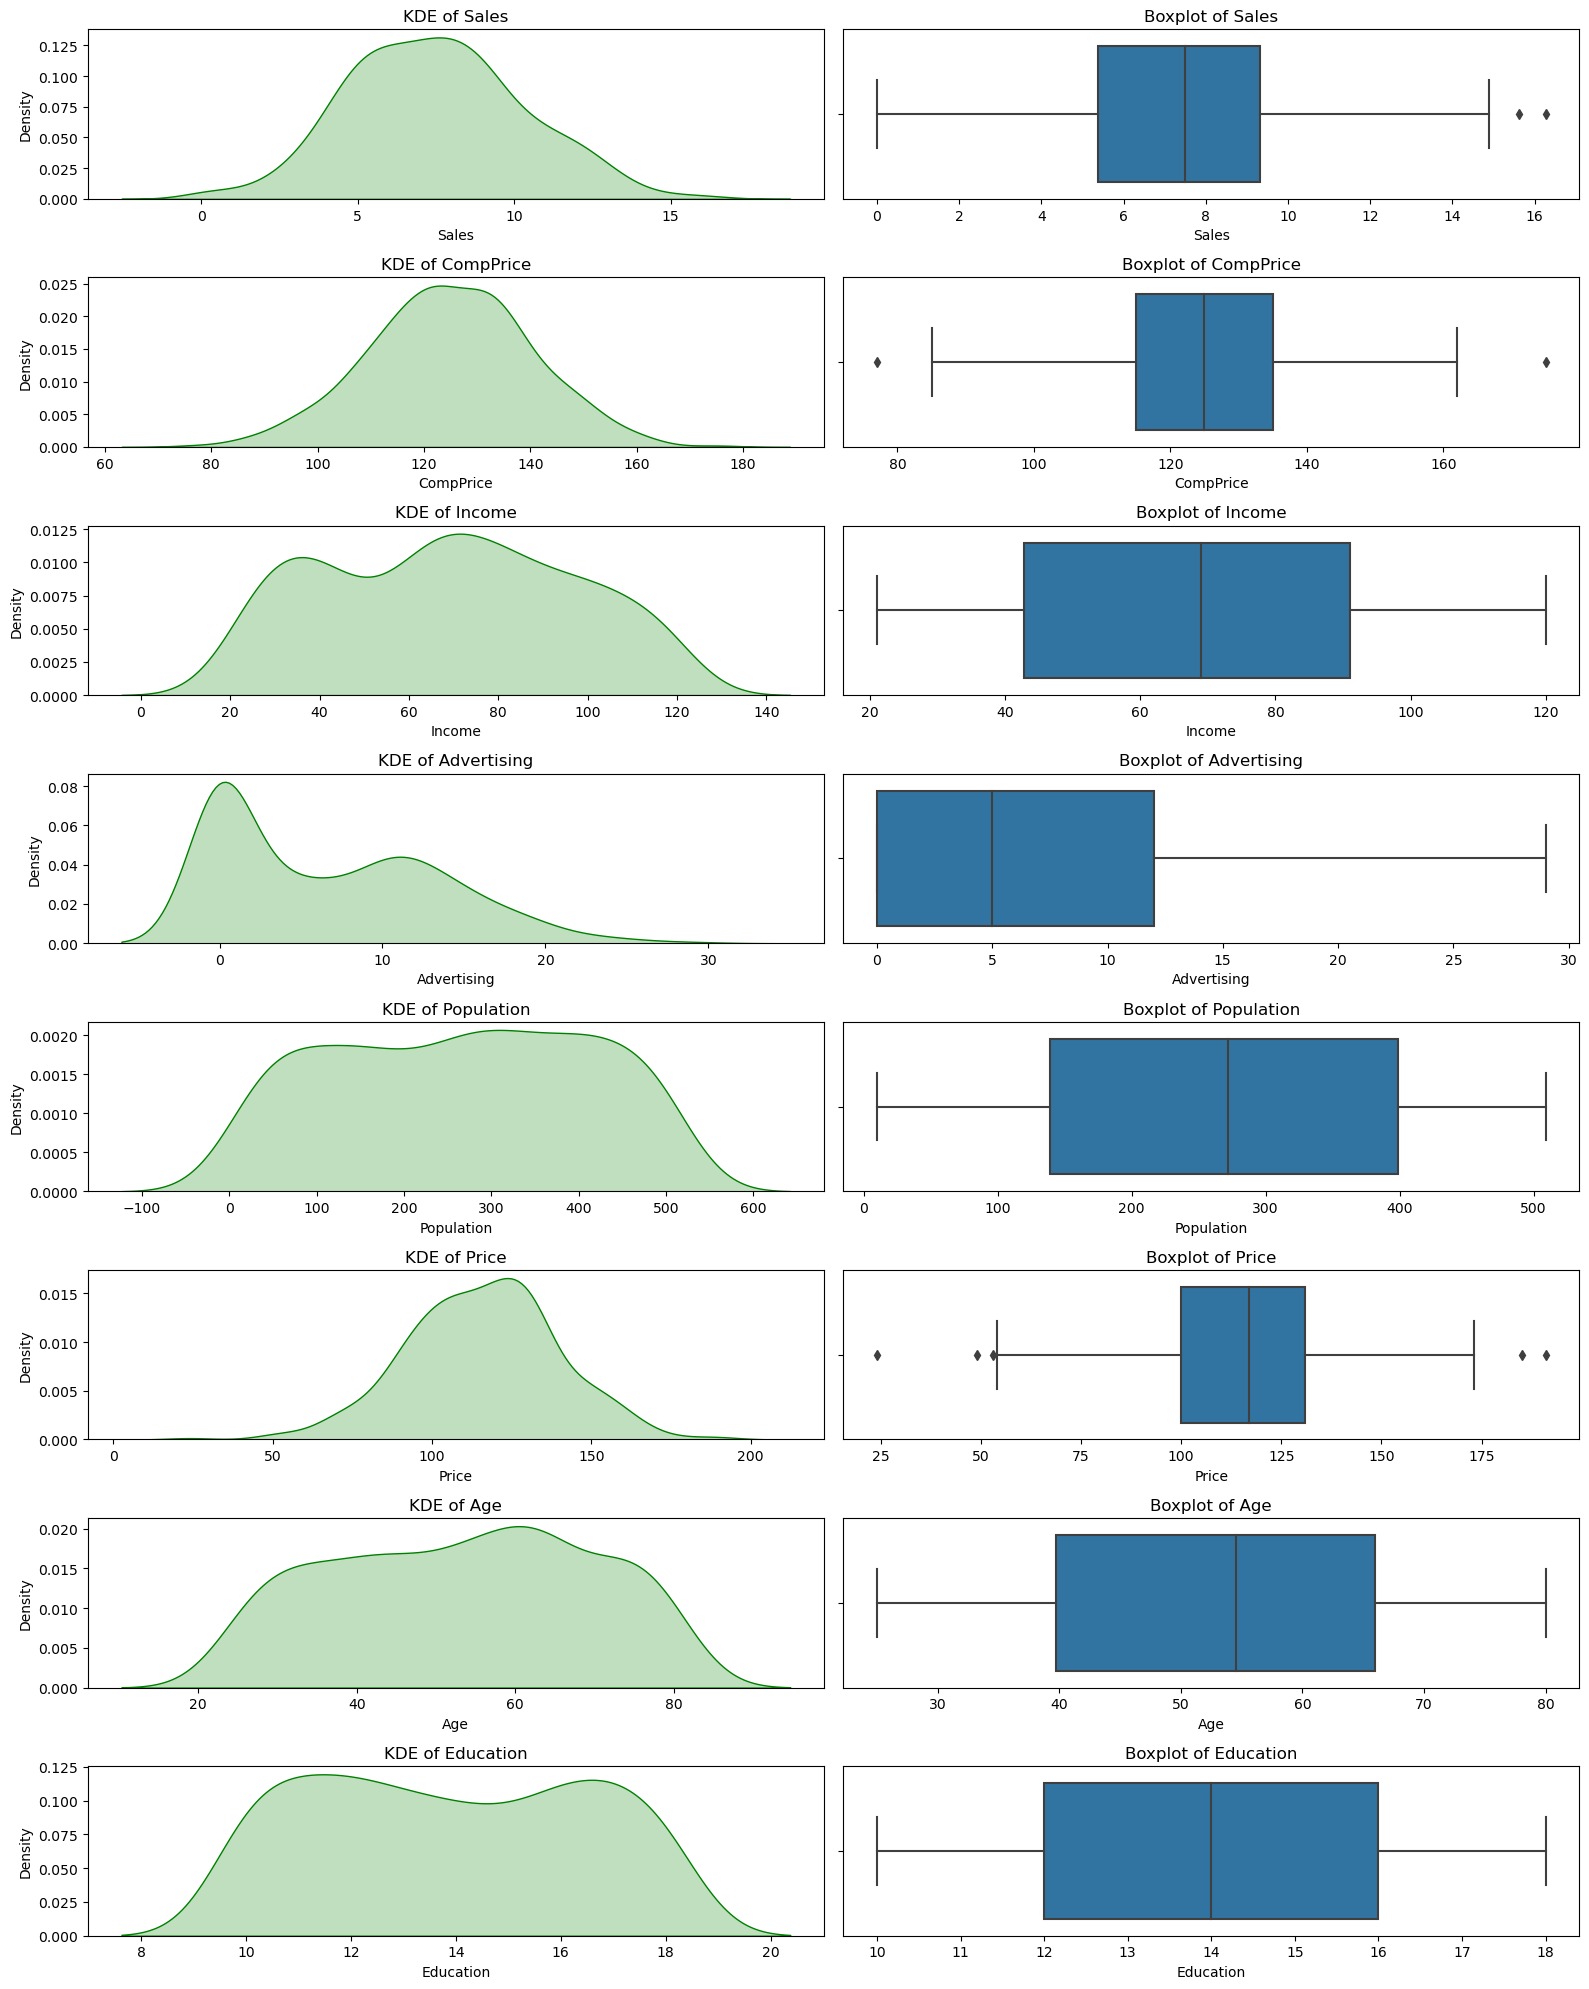

In [23]:
plt.figure(figsize=(16,20))

for i, col in enumerate(num_columns):
    
    # KDE Plot
    plt.subplot(len(num_columns), 2, 2*i+1)
    sns.kdeplot(x=df1[col], fill=True, color='g')
    plt.title(f"KDE of {col}")
    
    # Boxplot
    plt.subplot(len(num_columns), 2, 2*i+2)
    sns.boxplot(x=df1[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

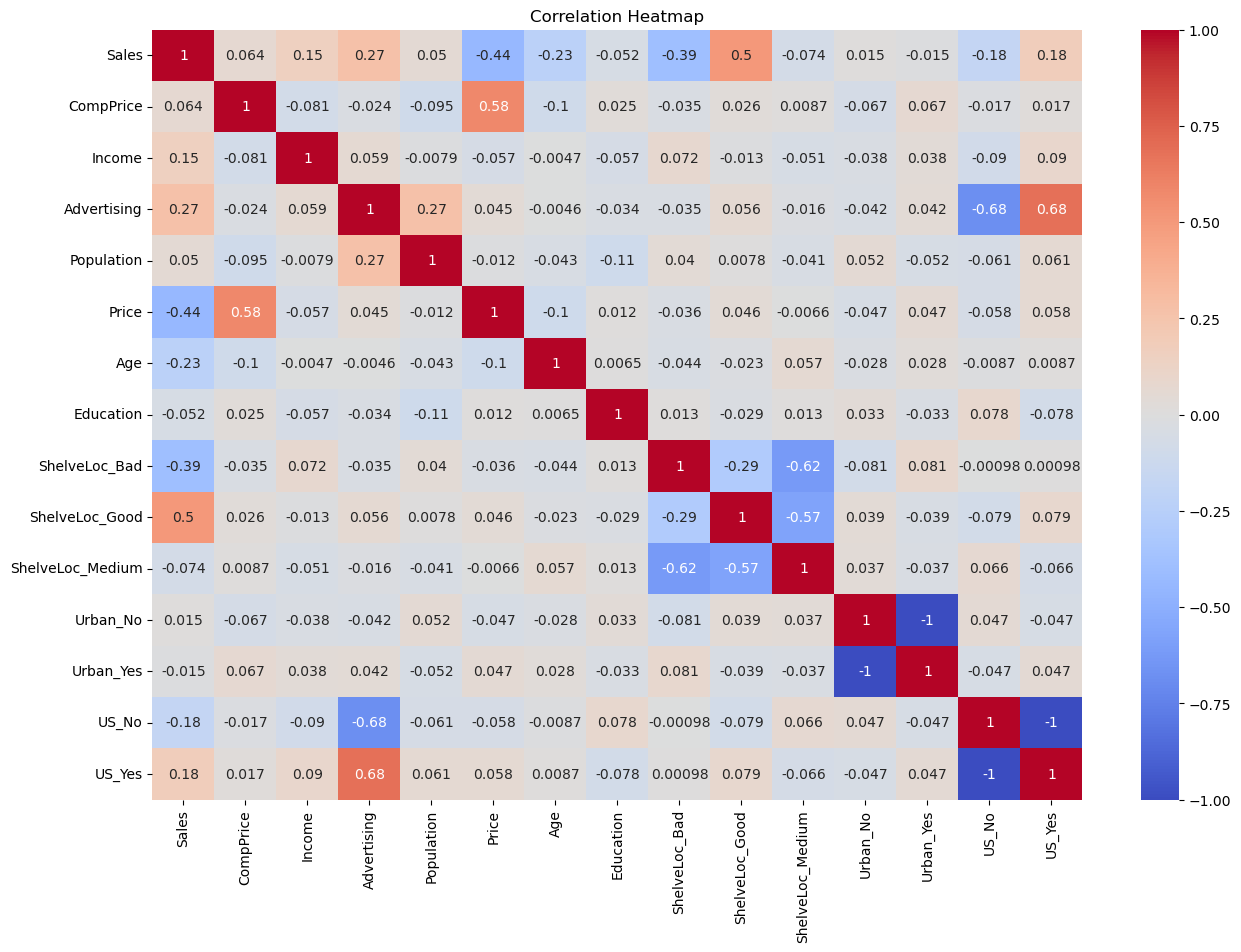

In [32]:
corr = df1.corr()

plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Random Forest Model

Since the target variable is continuous, we create a class of the value based on the mean

# <= 7.49 == "Small" and > 7.49 == "large"

In [33]:
df1["sales"]="small"
df1.loc[df1["Sales"]>7.49,"sales"]="large"
df1.drop(["Sales"], axis=1, inplace=True)

In [34]:
X=df1.iloc[:,0:14]
y=df1.iloc[:,14]

In [55]:
x_train, x_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
y_train.value_counts()

sales
small    164
large    156
Name: count, dtype: int64

In [57]:
model =RF(n_jobs=4,n_estimators = 150, oob_score =True,criterion ='entropy') 
model.fit(x_train,y_train)
model.oob_score_

0.790625

In [58]:
pred_train=model.predict(x_train)

In [59]:
accuracy_score(y_train, pred_train)

1.0

In [60]:
confusion_matrix(y_train, pred_train)

array([[156,   0],
       [  0, 164]], dtype=int64)

In [61]:
pred_test=model.predict(x_test)

In [62]:
accuracy_score(y_test, pred_test)

0.8125

In [63]:
confusion_matrix(y_test, pred_test)

array([[34,  9],
       [ 6, 31]], dtype=int64)

In [53]:
df_t=pd.DataFrame({'Actual':y_test, 'Predicted':pred_test})

In [54]:
df_t

,Actual,Predicted
169,large,large
376,large,large
281,large,large
105,small,large
198,small,small
...,...,...
253,small,small
386,small,small
301,small,large
90,small,small


# Conclusion

Since the accuracy of the training set is 100%, it shows that the model has perfectly learned the training data, which also indicates a possibility of overfitting. Therefore, we evaluate the model performance using test data.

The accuracy on the test dataset is 80%. From the confusion matrix of the test data, 31 instances of small and 33 instances of large are predicted correctly, while 9 instances of small are incorrectly predicted as large and 7 instances of large are incorrectly predicted as small

Overall, the Random Forest model performs well with good accuracy on unseen data, although there is slight overfitting observed in the training results.